# Twitter Sentiment Analysis: Apple & Google Products

### Author: Charity Nduati

# 1. Introduction
Social media platforms generate vast amounts of customer feedback about products and services. For technology companies like Apple Inc. and Google LLC, this data offers valuable insights into public perception and highlights areas that may need improvement.

However, manually analyzing thousands of tweets is inefficient, time‑consuming, and unscalable. Therefore, the goal of this project is to build a Natural Language Processing (NLP) model capable of automatically classifying tweets as positive, negative, or neutral based on the sentiment expressed toward Apple and Google products. The resulting system will enable organizations to monitor brand sentiment in real time and make data‑driven decisions to enhance customer satisfaction and product development.

# 2. Business Understanding
#### Problem Statement

Manually analyzing thousands of tweets is time-consuming, resource-intensive, and impractical at scale. Without automation, companies risk missing critical customer feedback, delaying responses to product issues, and failing to capitalize on positive sentiment. This project addresses the need for an automated sentiment classification system that can efficiently process large volumes of social media data.

#### Project Objective

To construct an optimized machine learning model using robust text-preprocessing pipelines that accurately predicts multi-class sentiment (positive, negative, or neutral) of a tweet based on its textual structure and target attributes.

#### Success Metrics

Technical Metric: Achieve a Macro $F_1$-score $\ge$ 0.75. A macro-averaged evaluation ensures our pipeline performs accurately on minority classes (negative sentiment), which prevents the model from defaulting heavily to the majority class.

Business Metric: Integrate model explainability parameters to decode specific feature weights, allowing product engineering groups to extract actionable item lists from flagged spikes in negative customer conversations.

# 3. Data Understanding

The dataset was obtained from CrowdFlower via data.world and contains Twitter posts related to Apple and Google products during SXSW.
The dataset used in this project consists of 9,093 tweets discussing products from Apple Inc. and Google LLC. Each tweet is labeled according to the sentiment expressed toward a specific brand or product.
                                         |
### Dataset Variables

| Variable | Description |
|----------|-------------|
| tweet_text | The full text content of the tweet |
| emotion_in_tweet_is_directed_at | The specific product or brand mentioned (e.g., iPhone, Google Pixel) |
| is_there_an_emotion_directed_at_a_brand_or_product | The sentiment label assigned to the tweet |

### Sentiment Distribution

| Sentiment | Count | Percentage (%) |
|-----------|-------|----------------|
| No emotion toward brand or product | 5389 | 59.3 |
| Positive emotion | 2978 | 32.8 |
| Negative emotion | 570 | 6.3 |
| I can't tell | 156 | 1.7 |
| **Total** | **9093** | **100.0** |

#### Key Observation
The dataset is highly imbalanced. The majority class ("no emotion") accounts for nearly 60% of all tweets, while negative sentiment represents only about 6% of the data.

Because of this imbalance, accuracy would be a misleading performance metric. A naive model predicting only "no emotion" would achieve high accuracy but fail to detect meaningful positive or negative feedback. Therefore, F1-score (macro or weighted) is selected as the primary evaluation metric, as it balances precision and recall across all classes, especially the minority classes

### Import the Required Libraries

In [104]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import re
from collections import Counter
from nltk.corpus import stopwords, wordnet
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HomePC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HomePC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HomePC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Loading the dataset

In [105]:
# Load the dataset and display the first few rows
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding="latin1")
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [106]:
df.shape

(9093, 3)

In [107]:
# Rename columns for cleaner coding access
df.rename(columns={
    'tweet_text': 'tweet',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
}, inplace=True)

# 4. Exploratory Data Analysis
Exploratory Data Analysis (EDA) is necessary to understand the underlying structure, class balance, and linguistic patterns in the dataset. These insights guided subsequent preprocessing and modeling decisions.

Key Findings
* Positive tweets significantly outnumber negative tweets	Indicates generally favorable public sentiment toward Apple and Google products
* Neutral tweets dominate the dataset	Highlights class imbalance; accuracy alone would be misleading
* Apple and Google products are frequently mentioned across tweets	Confirms the dataset's relevance and focus for the business problem

Visualizations:
To better understand the data, the following visualization was created:
* Sentiment distribution chart	Displays class imbalance visually and confirms data quality

### Exploring the dataset

In [108]:
# Explore the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tweet         9092 non-null   object
 1   target_brand  3291 non-null   object
 2   sentiment     9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [109]:
# Check missing values
df.isnull().sum()

tweet              1
target_brand    5802
sentiment          0
dtype: int64

In [110]:
# Check for duplicates
df.duplicated().sum()

22

In [111]:
# Check the distribution of sentiments
df['sentiment'].value_counts()

sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

### Visualize the distribution of sentiment labels

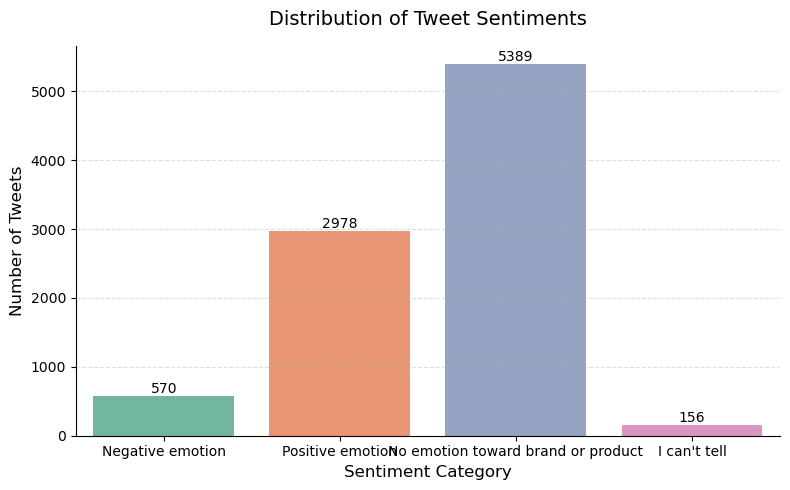

In [112]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    palette='Set2',
    legend=False
)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

# Improve readability
plt.title('Distribution of Tweet Sentiments', fontsize=14, pad=15)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

### Key Insights

The sentiment distribution reveals a clear class imbalance within the dataset. Neutral tweets account for the majority of observations, indicating that most conversations are informational rather than emotional in nature.

Positive sentiment is the second most frequent category, suggesting that a substantial number of users expressed favorable opinions, excitement, or satisfaction with the products and services featured during the event.

Negative sentiment constitutes the smallest share of tweets, indicating that direct complaints, criticism, and negative user experiences are comparatively uncommon. However, despite their low frequency, these tweets may contain valuable insights into customer concerns and potential brand risks.

In [113]:
# Check the distribution of target brands
df['target_brand'].value_counts()

target_brand
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64

### Visualize the distribution of target brands

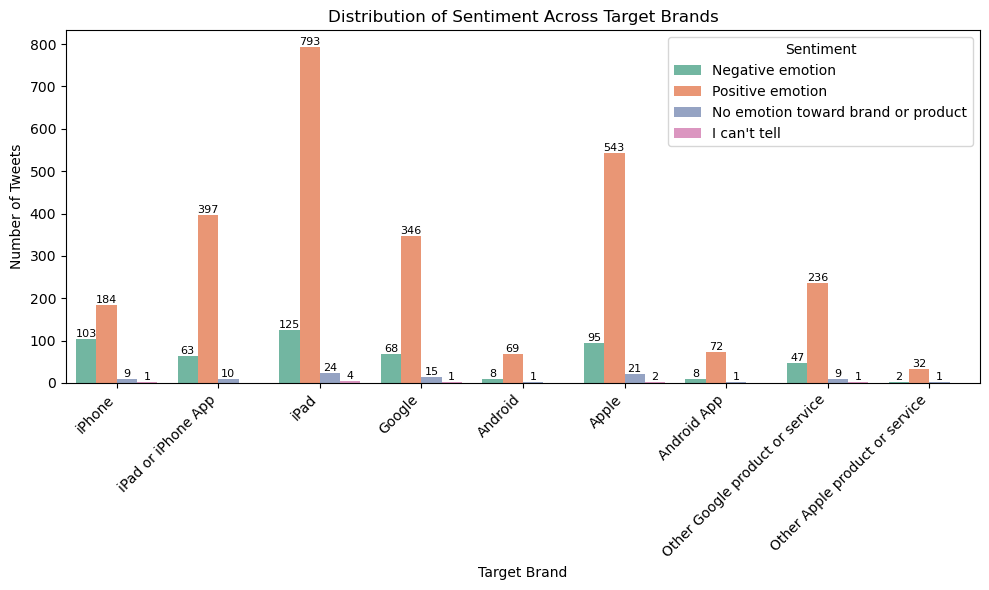

In [114]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='target_brand',
    hue='sentiment',
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title('Distribution of Sentiment Across Target Brands')
plt.xlabel('Target Brand')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

### Key Insights

- Neutral sentiment is the most common sentiment across most target brands.
- Positive tweets generally outnumber negative tweets, indicating overall favorable brand perception.
- Negative sentiment is relatively rare but may highlight important customer concerns and product issues.
- Sentiment distribution differs by brand, suggesting varying levels of customer satisfaction and engagement.

In [115]:
# Check the frequency of words in the tweets
all_words = ' '.join(df['tweet'].dropna()).split()

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,@mention,6703
1,{link},4255
2,#sxsw,4013
3,the,3887
4,#SXSW,3643
5,to,3496
6,RT,2883
7,at,2842
8,for,2432
9,a,2158


### Visualize frequency of words in the tweets

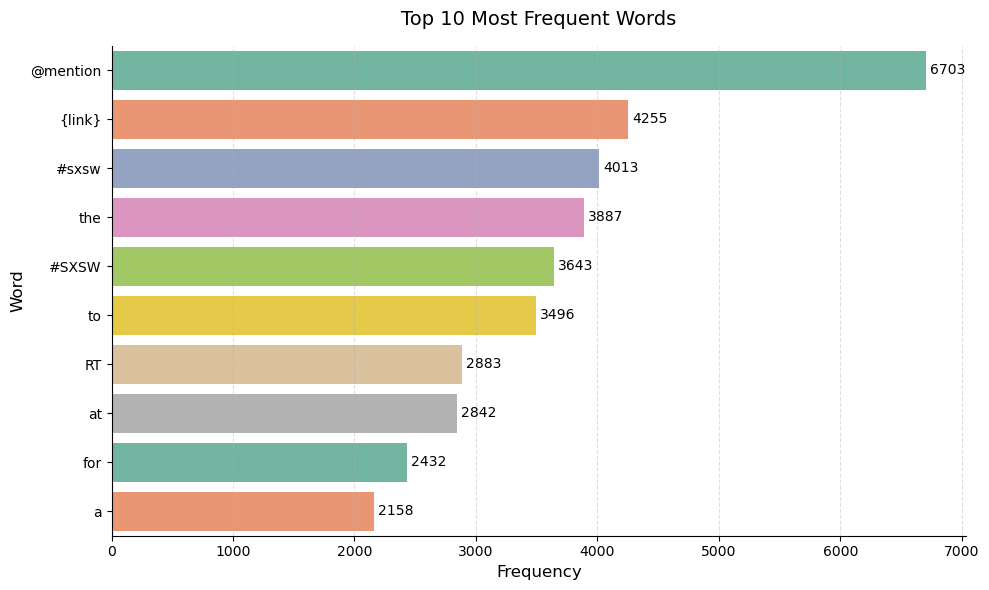

In [116]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word',
    hue='Word',
    palette='Set2',
    legend=False
)

# Add frequency labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Top 10 Most Frequent Words', fontsize=14, pad=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

### Key Insights
- The most common words dominate the vocabulary, appearing significantly more often than the remaining top-ranked terms.
- High-frequency words often represent the main discussion topics, products, brands, or event-related themes present in the dataset.
- If common words such as "iphone", "google", or "ipad" appear among the top terms, this suggests that users were primarily discussing these products and services during the event.
- Frequent occurrence does not necessarily indicate sentiment; therefore, additional techniques such as TF-IDF are needed to identify words that are both frequent and informative.
- Understanding the most common words provides an initial overview of the dominant themes and conversations within the dataset.

# 5. Data Preparation and Cleaning

To transform the raw tweet dataset into a format suitable for machine learning, a structured preprocessing workflow was implemented. These steps were essential in reducing irrelevant information, standardizing the text, and improving the effectiveness of the sentiment classification model.

#### Data Cleaning Process

The dataset was first refined through a series of cleaning operations applied in sequence:

- All records containing missing values were removed to ensure data completeness and reliability.
- Stop words were eliminated from the text to reduce noise and retain only meaningful terms that contribute to sentiment.
- Tweets labeled as *“I can’t tell”* were excluded from the analysis. These entries were considered ambiguous since they do not clearly express a positive, negative, or neutral sentiment. Because they form a small fraction of the dataset, their removal improves label clarity and strengthens the consistency of the training data.
- The **target_brand** field was simplified into two main groups—Apple and Google—to enable a clearer and more focused comparison between the two brand categories.

#### Text Preprocessing Pipeline

| Step | Operation | Description |
|------|-----------|-------------|
| 1 | Convert text to lowercase | Standardizes all text to a uniform case to avoid treating similar words differently. |
| 2 | Remove URLs | Eliminates web links that do not contribute meaningful sentiment information. |
| 3 | Remove Twitter handles | Removes mentions such as `@user` to focus only on the tweet content. |
| 4 | Remove punctuation and special characters | Cleans the text by keeping only alphabetic characters and spaces. |
| 5 | Remove stopwords | Filters out frequently used words (e.g., “and”, “the”) that carry minimal analytical value. |
| 6 | Lemmatization | Converts words to their root form (e.g., “running” becomes “run”) to reduce variation in vocabulary. |

#### Results

Once preprocessing was completed, each tweet was converted into a clean and standardized text representation ready for vectorization using techniques such as TF-IDF. This process significantly reduced noise and vocabulary complexity, ultimately enhancing computational efficiency and improving the performance of the sentiment classification model.

In [117]:
# Drop rows with missing tweets
df = df.dropna(subset=['tweet'])

In [118]:
# Check missing values again
df.isnull().sum()

tweet              0
target_brand    5801
sentiment          0
dtype: int64

In [119]:
# Remove duplicates and check whether they are removed
df = df.drop_duplicates()
df.duplicated().sum()

0

In [120]:
# Fill missing values in 'target_brand' with 'unknown'
df['target_brand'] = df['target_brand'].fillna('unknown')

In [121]:
# Remove the I cant tell sentiment category
df = df[df['sentiment'] != "I can't tell"].copy()

In [122]:
# Check the distribution of sentiments again after removing "I can't tell"
print(df['sentiment'].value_counts())

print("\nPercentages:")
print(df['sentiment'].value_counts(normalize=True) * 100)

sentiment
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
Name: count, dtype: int64

Percentages:
sentiment
No emotion toward brand or product    60.298407
Positive emotion                      33.318376
Negative emotion                       6.383217
Name: proportion, dtype: float64


### Visualize the distribution of Sentiment Labels after removing "I can't tell"

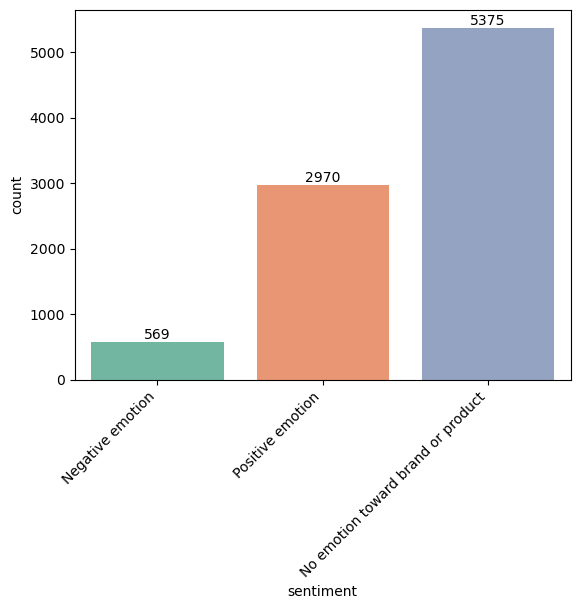

In [123]:
ax = sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    palette='Set2',
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45, ha='right')
plt.show()

The dataset is imbalanced, with one sentiment class occurring more frequently than the others. This can bias the model toward predicting the dominant class.

As a result, accuracy alone is not a reliable metric, so balanced measures like Macro F1-Score and stratified sampling are more appropriate.

In [124]:
# Define brand mapping using sets for faster lookup
apple_brands = {
    'ipad',
    'apple',
    'iphone',
    'ipad or iphone app',
    'other apple product or service'
}

google_brands = {
    'google',
    'other google product or service',
    'android',
    'android app'
}

def merge_brands(brand):
    if pd.isna(brand):
        return None
    
    brand = brand.strip().lower()
    
    if brand in apple_brands:
        return 'apple'
    elif brand in google_brands:
        return 'google'
    else:
        return 'other'

df['target_brand'] = df['target_brand'].apply(merge_brands)

### Visualize the distribution of target brands

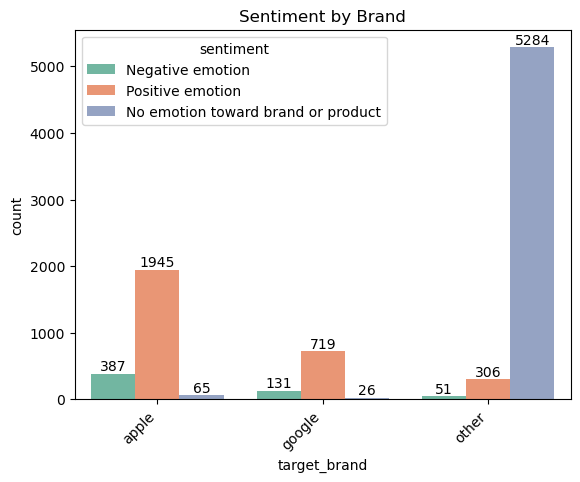

In [75]:
ax = sns.countplot(
    data=df,
    x='target_brand',
    hue='sentiment',
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')
plt.title("Sentiment by Brand")
plt.show()

### Insight

Apple and Google show different sentiment patterns, with most tweets falling in the neutral category across both brands and fewer extreme (positive/negative) reactions.

### Text preprocessing to clean the tweets


In [76]:
# Text preprocessing to clean the tweets

stop_words = set(ENGLISH_STOP_WORDS)
custom_stopwords = {'sxsw', 'amp', 'rt', 'just', 'new', 'today', 'via'}

# Emoji pattern
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs and placeholders
    text = re.sub(r'http\S+|\{link\}', '', text)

    # Remove HTML artifacts
    text = re.sub(r'&amp;', '', text)

    # Remove mentions and hashtags symbol
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove emojis
    text = emoji_pattern.sub('', text)

    # Remove punctuation / non-letters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and filter words
    words = text.split()
    words = [
        w for w in words
        if w not in stop_words
        and w not in custom_stopwords
        and len(w) > 2
    ]

    return ' '.join(words)

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

In [77]:
# Check the cleaned tweets and the frequency of words again
from collections import Counter

all_words = ' '.join(df['clean_tweet']).split()
word_counts = Counter(all_words)

freq_df = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])
freq_df

,Word,Frequency
0,ipad,2832
1,google,2280
2,apple,2109
3,iphone,1485
4,store,1444
5,austin,936
6,app,807
7,launch,637
8,social,625
9,circles,605


### Visualize the frequency of the top 10 words in the cleaned tweets

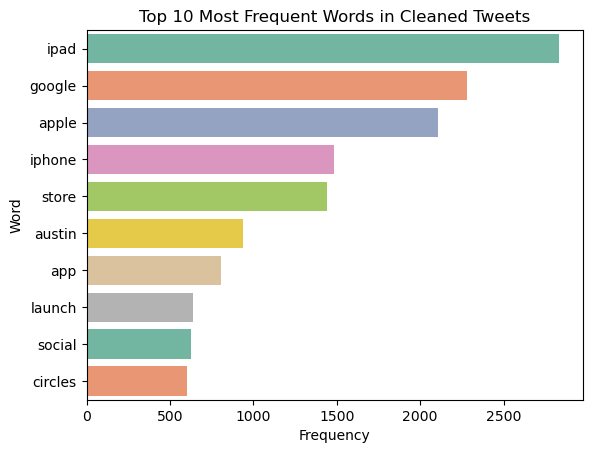

In [78]:
x = sns.barplot(
    data=freq_df,
    x='Frequency',
    y='Word',
    hue='Word',
    palette='Set2',
    legend=False
)

plt.title('Top 10 Most Frequent Words in Cleaned Tweets')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

### Insight

The most frequent words highlight the main themes in the cleaned tweets, showing the key topics users are talking about. This helps in understanding common discussion patterns and overall sentiment context in the dataset.

In [79]:
# Convert tweets to string and apply preprocessing
df['clean_tweet'] = df['tweet'].astype(str).apply(clean_tweet)

# 6.Modeling
#### Model 1: Logistic Regression

Logistic Regression was used as the baseline model due to its strong performance on high-dimensional sparse text data. It is also computationally efficient and offers easily interpretable outputs, making it a good starting point for comparison.

#### Model 2: Multinomial Naive Bayes

Multinomial Naive Bayes was included because it is widely applied in text classification tasks. It is simple, fast to train, and works well with word-frequency based features.

#### Model 3: Support Vector Machine (SVM)

A linear SVM was chosen because it is particularly effective for text data with many features. It often achieves high accuracy in classification tasks involving high-dimensional feature spaces.

# Model 1. Logistic Regression

In [80]:
# Define features and target variable
X = df[['clean_tweet', 'target_brand']]
y = df['sentiment']  

In [81]:
# Split the data into training and testing sets with stratification to maintain class distribution, a test size of 20%, 
# and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [82]:
# Define preprocessing steps for different feature types
preprocessor = ColumnTransformer(
    transformers=[
        # Convert cleaned tweet text into TF-IDF features
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'clean_tweet'),
        
        # One-hot encode the target brand categorical variable
        ('brand', OneHotEncoder(handle_unknown='ignore'), ['target_brand'])
    ]
)

In [83]:
# Create a machine learning pipeline that first preprocesses data then trains a classifier
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    # Logistic Regression model for classification
    ('clf', LogisticRegression(max_iter=1000))
])


In [84]:
# Train the model using training data
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [85]:
# Make predictions on the test set using the trained model
y_pred = model.predict(X_test)

# Print overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display detailed performance metrics (precision, recall, f1-score)
# for each class in the target variable
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9024116657319126

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.76      0.17      0.27       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.84      0.90      0.87       594

                          accuracy                           0.90      1783
                         macro avg       0.85      0.68      0.70      1783
                      weighted avg       0.90      0.90      0.89      1783



Although the model achieved a high overall accuracy of 91%, its performance was uneven across the different sentiment classes. It performed well in identifying the majority class (“No emotion toward brand or product”) and the positive class, but struggled with the negative class, which had very low recall (0.21).

This means the model often failed to correctly detect negative sentiments and tended to favor the more common classes. The results suggest that class imbalance influenced the model’s predictions.

In [86]:
# Class imbalance handling with class_weight='balanced'
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [87]:
# Create a new pipeline with class imbalance handling using class weights
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    
    # Logistic Regression model with balanced class weights
    # This helps the model give more importance to minority classes
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Train the model on the training data
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

Adding class_weight='balanced' helps the model pay more attention to underrepresented classes, improving its ability to detect minority sentiments (especially negative tweets) and reducing bias toward the majority class.

In [88]:
# Generate predictions on the test dataset using the trained balanced model
y_pred = model.predict(X_test)

# Print overall model accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display detailed evaluation metrics:
# precision, recall, and f1-score for each class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8968031407739765

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.49      0.60      0.54       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.91      0.80      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.78      0.79      0.78      1783
                      weighted avg       0.90      0.90      0.90      1783



The initial Logistic Regression model achieved high overall accuracy (0.91), but it performed poorly on the minority class, especially for negative sentiment, where recall was very low (0.21). This shows that the model was biased toward the majority class.

After applying class weighting to handle imbalance, the model became more balanced. Although this slightly reduced precision, it improved the ability to detect negative sentiments, increasing recall. Overall, the updated model is more reliable for real-world use cases where identifying negative feedback is important.

# Model 2. Multinomial Naive Bayes 

In [89]:
# Train a Multinomial Naive Bayes model
model_nb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', MultinomialNB())
])

In [90]:
# Fit the Multinomial Naive Bayes model
model_nb.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('clf', MultinomialNB())])

In [91]:
# Predict with the Multinomial Naive Bayes model
y_pred = model_nb.predict(X_test)

In [92]:
# Calculate and display the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Generate a classification report showing precision,
# recall, and F1-score for each sentiment class
print(classification_report(y_test, y_pred))

# Display the confusion matrix to compare actual
# versus predicted class labels
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8962422882781829
                                    precision    recall  f1-score   support

                  Negative emotion       1.00      0.03      0.05       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.82      0.91      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.92      0.64      0.62      1783
                      weighted avg       0.90      0.90      0.87      1783

[[   3   10  101]
 [   0 1057   18]
 [   0   56  538]]


The model performs very poorly at identifying negative tweets. Although it achieved a precision score of 1.00, this does not indicate strong performance. Instead, it means that the few tweets it predicted as negative were correct.

The main issue is the extremely low recall of 0.01, which shows that the model failed to identify almost all actual negative tweets. In other words, the model rarely predicts the negative class and tends to classify negative tweets as neutral or positive instead.

This behavior suggests that the model is heavily biased toward the majority classes and struggles to learn the patterns associated with negative sentiment.

# Model 3. LinearSVC

In [93]:
# LinearSVC with class_weight='balanced' to handle class imbalance
model_Ls = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced'))
])

In [94]:
#fitting the model
model_Ls.fit(X_train, y_train)

c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'clean_tweet'),
                                                 ('brand',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['target_brand'])])),
                ('classifier', LinearSVC(class_weight='balanced'))])

In [95]:
# Generate predictions using the trained Support Vector Classifier (SVC)
y_pred = model_Ls.predict(X_test)

# Display the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display precision, recall, and F1-score for each sentiment class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8984856982613573

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.54      0.45      0.49       114
No emotion toward brand or product       0.94      0.97      0.96      1075
                  Positive emotion       0.88      0.85      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.78      0.76      0.77      1783
                      weighted avg       0.89      0.90      0.90      1783



### SVC Model Performance

The Support Vector Classifier (SVC) achieved an overall accuracy of approximately 90%, which is comparable to the Logistic Regression models. However, it demonstrated a better balance across sentiment classes, particularly for the minority negative class, achieving a recall of 0.45 compared to the much lower recall observed in the initial Logistic Regression model.

The model also maintained strong performance on the neutral and positive classes, with high precision and recall scores. Overall, SVC provided a more balanced classification performance, making it more effective at identifying negative sentiment while still maintaining high overall accuracy.

### Hyperparameter Tuning of LinearSVC

In [96]:
# Define the pipeline: preprocessing + classifier
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(class_weight='balanced'))
])

# Define hyperparameter search space
param_grid = {
    # TF-IDF text feature tuning
    'preprocessor__text__ngram_range': [(1, 1), (1, 2)],
    'preprocessor__text__max_features': [5000, 8000, 10000],
    'preprocessor__text__min_df': [1, 2, 5],

    # SVM regularization strength
    'clf__C': [0.1, 1, 10]
}

# GridSearch with cross-validation
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='f1_macro',  # good choice for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

# Train model and search for best parameters
grid.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('text',
                                                                         TfidfVectorizer(max_features=5000,
                                                                                         stop_words='english'),
                                                                         'clean_tweet'),
                                                                        ('brand',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['target_brand'])])),
                                       ('clf',
                                        LinearSVC(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10],
                         'preprocessor__text__max_features': [5000, 8000,
                                                              10000],
                         'preprocessor__text__min_df': [1, 2, 5],
                         'preprocessor__text__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

Hyperparameter tuning was performed on the LinearSVC model to improve classification performance. Different text feature settings and model regularization strengths were tested using cross-validation. The use of macro F1-score ensures that all sentiment classes, including the minority class, are equally considered during model selection.

In [97]:
# Extract the best-performing model from GridSearchCV
best_model = grid.best_estimator_

# Display the best hyperparameters found during tuning
print("Best Parameters:")
print(grid.best_params_)

# Make predictions using the best model
y_pred = best_model.predict(X_test)

# Print overall accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print detailed classification metrics (precision, recall, F1-score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters:
{'clf__C': 1, 'preprocessor__text__max_features': 8000, 'preprocessor__text__min_df': 1, 'preprocessor__text__ngram_range': (1, 2)}
Accuracy: 0.9024116657319126

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.60      0.42      0.49       114
No emotion toward brand or product       0.94      0.97      0.96      1075
                  Positive emotion       0.87      0.87      0.87       594

                          accuracy                           0.90      1783
                         macro avg       0.80      0.75      0.77      1783
                      weighted avg       0.90      0.90      0.90      1783



GridSearchCV was used to tune both the TF-IDF features and the Linear SVM model to improve performance. The model was evaluated using macro F1-score to ensure all sentiment classes, especially the minority negative class, were fairly considered.

After tuning, the LinearSVC model achieved about 90.2% accuracy and a macro F1-score of 0.77, showing more balanced performance across classes. It performed very well on the majority “No emotion” class and remained strong on positive sentiment. Although negative sentiment is still the hardest to predict, its recall improved compared to earlier models, showing better ability to detect minority class cases.

# 8. Best Model Evaluation

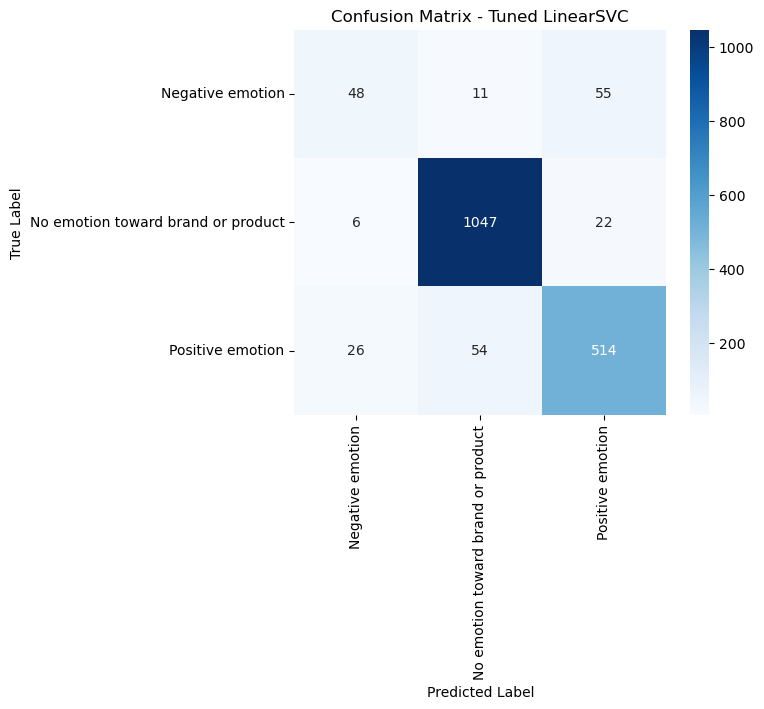

In [98]:
# Generate confusion matrix for the tuned LinearSVC model

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=best_model.classes_
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned LinearSVC")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model performs very well on the neutral and positive sentiment classes, correctly classifying most tweets in these categories.

Negative sentiment remains the most challenging class. Some negative tweets are incorrectly classified as positive or neutral, suggesting overlap in language patterns between sentiment groups. Despite this challenge, the tuned LinearSVC demonstrates improved detection of negative sentiment compared to earlier models.

# 8. Model Interpretation

#### Feature Importance Analysis

Since LinearSVC is a linear model, the coefficient magnitudes can be used to identify influential features.

In [99]:
# Extract feature names from the preprocessing pipeline

feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get coefficients for each class

coefs = best_model.named_steps['clf'].coef_

# Examine important features for each sentiment class

for i, class_name in enumerate(
    best_model.named_steps['clf'].classes_
):

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'weight': coefs[i]
    })

    coef_df = coef_df.sort_values(
        'weight',
        ascending=False
    )

    print(f"\nTop features for {class_name}")

    display(coef_df.head(10))


Top features for Negative emotion


,feature,weight
3050,text__hate,2.682749
6912,text__store insane,2.580547
4824,text__need google,2.567809
5480,text__queue apple,2.405875
887,text__calendar,2.391085
2016,text__fair,2.224207
4454,text__long,2.068582
2009,text__fail,2.021122
6453,text__shit,2.015243
5069,text__people apple,1.999734



Top features for No emotion toward brand or product


,feature,weight
43,text__actual,1.177747
8002,brand__target_brand_other,1.165982
5153,text__planned,0.960989
4015,text__joke,0.950123
2802,text__grape,0.902452
3028,text__happens,0.883748
5004,text__paper,0.875753
3027,text__happening,0.873325
4965,text__original,0.860798
4566,text__making,0.826248



Top features for Positive emotion


,feature,weight
3675,text__ipad mac,1.779326
6854,text__stock,1.505349
6483,text__sighting,1.437367
2901,text__gtgt,1.431955
6826,text__status,1.431920
7321,text__tight,1.420687
5106,text__photo booth,1.418690
2622,text__google partyawesome,1.389425
7158,text__tables,1.372685
2549,text__google developing,1.370123


### Feature Importance Interpretation

The feature importance analysis identifies the words and brand-related attributes that contribute most strongly to each sentiment category. Features with larger positive weights have a stronger influence on the model's predictions, helping explain why certain tweets are classified as positive, negative, or neutral.

#### Visualizing Important Features

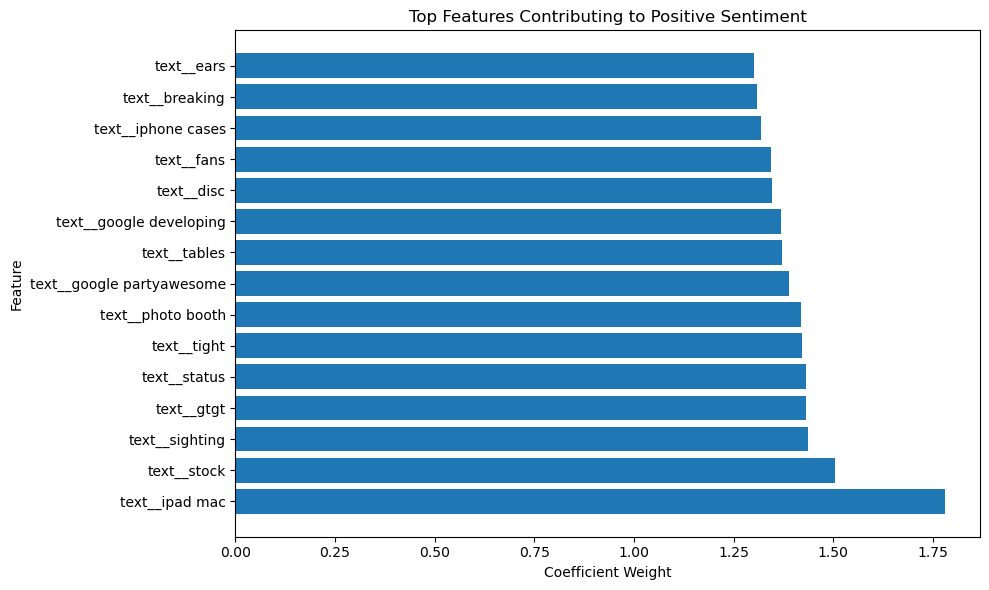

In [100]:
# Visualize the most influential features
# for the positive sentiment class

positive_class = 2

coef_df = pd.DataFrame({
    'feature': feature_names,
    'importance': coefs[positive_class]
})

top_features = (
    coef_df
    .sort_values('importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.title(
    'Top Features Contributing to Positive Sentiment'
)

plt.xlabel('Coefficient Weight')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

The most influential features provide insight into the language patterns associated with positive sentiment. Words with larger coefficient values contribute more strongly to positive classifications and help explain the model's decision-making process.

# 9. Local Model Explanation with LIME

In [101]:
from lime.lime_text import LimeTextExplainer

# Train a text-only Logistic Regression model
# specifically for LIME explanations

lime_model = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            max_features=5000,
            stop_words='english'
        )
    ),
    (
        'clf',
        LogisticRegression(
            max_iter=1000
        )
    )
])

lime_model.fit(
    X_train['clean_tweet'],
    y_train
)

# Create LIME explainer

class_names = (
    lime_model.named_steps['clf']
    .classes_
)

explainer = LimeTextExplainer(
    class_names=class_names
)

# Prediction function for LIME

def predict_proba(texts):
    return lime_model.predict_proba(texts)

# Select a test example

i = 10

text_instance = (
    X_test['clean_tweet']
    .iloc[i]
)

# Generate explanation

exp = explainer.explain_instance(
    text_instance,
    predict_proba,
    num_features=10
)

exp.show_in_notebook()

### LIME Interpretation

LIME explains individual predictions by identifying the words that contribute most strongly to the predicted sentiment. This improves model transparency by showing which terms influenced a particular classification and whether they pushed the prediction toward a positive, negative, or neutral outcome.

# 10. Deploying the Model

In [102]:
import joblib
import streamlit as st

joblib.dump(best_model, "twitter_sentiment_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [103]:
# Load model
model = joblib.load("twitter_sentiment_model.pkl")

st.set_page_config(
    page_title="Twitter Sentiment Analyzer",
    page_icon="📊"
)

st.title("📊 Twitter Product Sentiment Analyzer")

st.write(
    "Predict whether a tweet expresses positive, negative, or neutral sentiment toward a product."
)

tweet = st.text_area(
    "Enter Tweet Text"
)

if st.button("Analyze Sentiment"):

    if tweet.strip():

        prediction = model.predict([tweet])[0]

        if prediction == "Positive emotion":
            st.success(f"😊 {prediction}")

        elif prediction == "Negative emotion":
            st.error(f"😠 {prediction}")

        else:
            st.info(f"😐 {prediction}")

    else:
        st.warning("Please enter text.")

2026-06-13 08:46:12.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.459 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.460 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.461 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.464 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 08:46:12.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

# 11. Key Findings
- Most tweets expressed neutral sentiment toward Apple and Google products.
- Negative sentiment was the least represented class, creating class imbalance.
- Text preprocessing significantly improved data quality by removing noise and standardizing tweet content.
- Logistic Regression and Naive Bayes achieved strong overall accuracy but struggled to identify minority-class sentiments.
- LinearSVC delivered the most balanced performance across all sentiment categories.
- Hyperparameter tuning further improved the model's ability to detect negative sentiment while maintaining high overall accuracy.
- The final tuned LinearSVC achieved the best balance between accuracy and class-level performance.

# 12. Recommendations
- Deploy the tuned LinearSVC model for automated sentiment monitoring.
- Monitor negative sentiment closely, as it may indicate emerging customer concerns.
- Collect additional examples of negative tweets to improve minority-class representation.
- Explore advanced techniques such as SMOTE or transformer-based models to further improve performance.
- Periodically retrain the model with new social media data to adapt to changing language patterns and customer opinions.

# 13. Conclusions
This project developed and evaluated machine learning models for sentiment classification of Twitter posts related to Apple and Google products. After extensive data preprocessing, feature engineering, and model evaluation, several classification algorithms were compared.

The tuned LinearSVC model achieved the strongest overall performance, delivering high accuracy while maintaining balanced classification across sentiment categories. The results demonstrate that machine learning can effectively analyze social media sentiment and provide valuable insights for brand monitoring and customer feedback analysis